# 01 EDA — Bank Marketing Dataset

Цель ноутбука: изучить датасет, показать распределения, зависимости и написать выводы по графикам.

Основная задача проекта — бинарная классификация: предсказать, оформит ли клиент срочный депозит (`y`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT / "src"))

from preprocessing import load_data

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "bank-full.csv"
FIGURES_DIR = PROJECT_ROOT / "report" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = load_data(DATA_PATH)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 1. Общая информация о датасете

Проверяем размер, типы данных, пропуски и дубли.

In [2]:
print("shape:", df.shape)
df.info()

shape: (45211, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


In [4]:
print("missing values:")
print(df.isna().sum().sort_values(ascending=False))

print("\nduplicates:", df.duplicated().sum())

missing values:
age          0
day          0
poutcome     0
previous     0
pdays        0
campaign     0
duration     0
month        0
contact      0
job          0
loan         0
housing      0
balance      0
default      0
education    0
marital      0
y            0
dtype: int64

duplicates: 0


**Вывод:** датасет подходит под требования проекта: в нём больше 10 000 строк и больше 10 колонок.  
Пропуски в стандартном формате `NaN` отсутствуют, но в категориальных признаках есть значения типа `unknown`. Их не удаляем автоматически, потому что это отдельная категория, которая может нести информацию.

## 2. Распределение таргета

y
no     39922
yes     5289
Name: count, dtype: int64
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


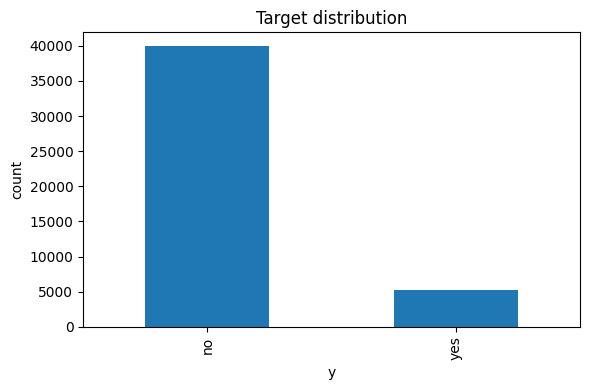

In [5]:
print(df["y"].value_counts())
print(df["y"].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
df["y"].value_counts().plot(kind="bar")
plt.title("Target distribution")
plt.xlabel("y")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_target_distribution.png", dpi=150)
plt.show()

**Вывод:** классы несбалансированы: клиентов с `y = yes` заметно меньше, чем клиентов с `y = no`.  
Поэтому accuracy не подходит как главная метрика: модель может часто предсказывать `no` и получать неплохую accuracy, но плохо находить клиентов с положительным откликом.  
Основной метрикой выбираем PR-AUC, дополнительно смотрим F1, precision, recall и ROC-AUC.

## 3. Категориальные признаки и отклик

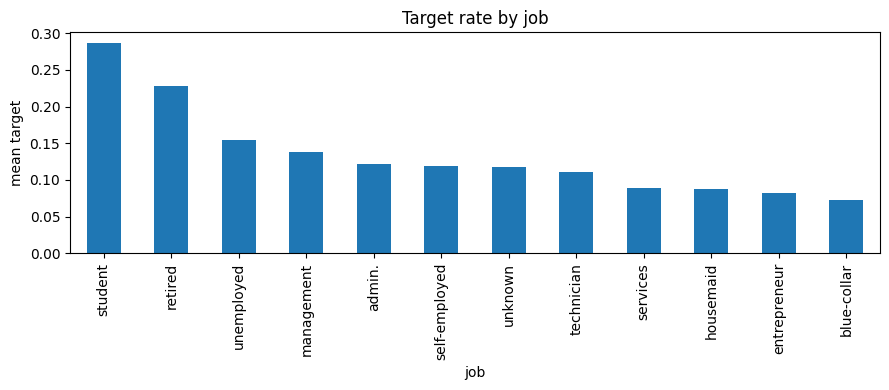

job
student          0.286780
retired          0.227915
unemployed       0.155027
management       0.137556
admin.           0.122027
self-employed    0.118429
unknown          0.118056
technician       0.110570
services         0.088830
housemaid        0.087903
entrepreneur     0.082717
blue-collar      0.072750
Name: y, dtype: float64

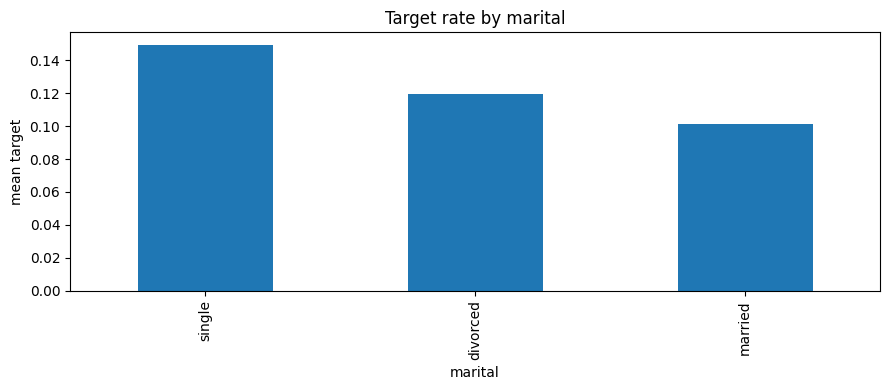

marital
single      0.149492
divorced    0.119455
married     0.101235
Name: y, dtype: float64

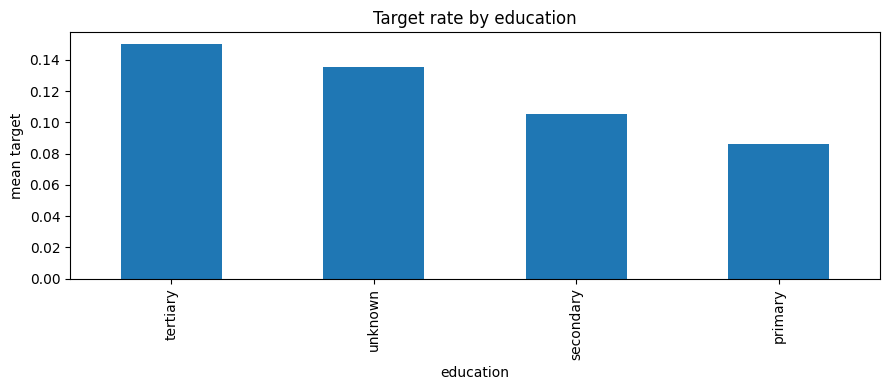

education
tertiary     0.150064
unknown      0.135703
secondary    0.105594
primary      0.086265
Name: y, dtype: float64

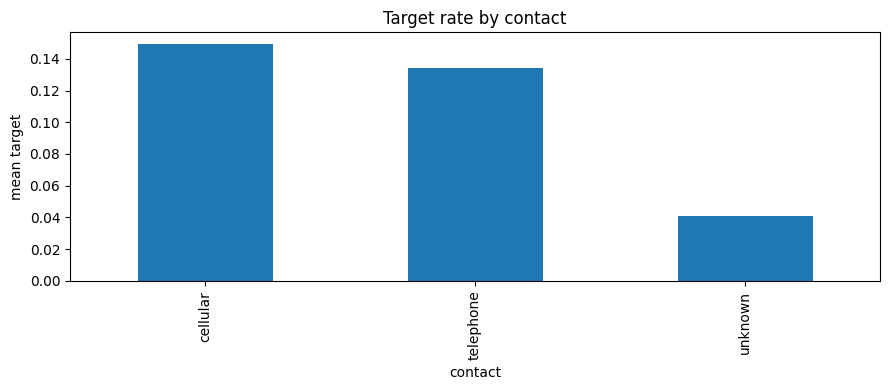

contact
cellular     0.149189
telephone    0.134205
unknown      0.040707
Name: y, dtype: float64

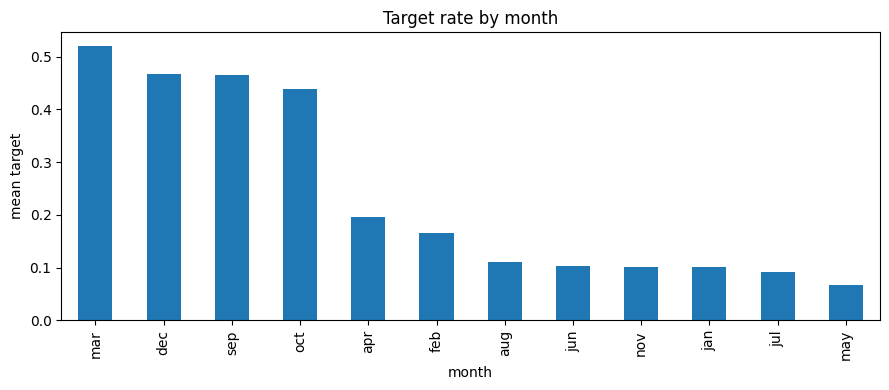

month
mar    0.519916
dec    0.467290
sep    0.464594
oct    0.437669
apr    0.196794
feb    0.166478
aug    0.110133
jun    0.102228
nov    0.101511
jan    0.101212
jul    0.090935
may    0.067195
Name: y, dtype: float64

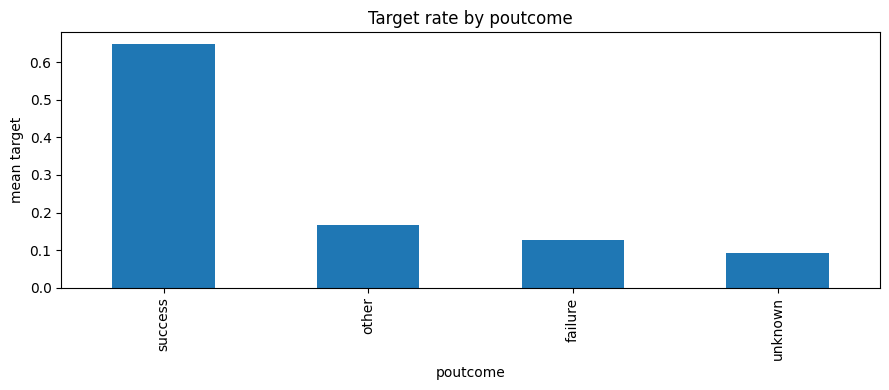

poutcome
success    0.647253
other      0.166848
failure    0.126097
unknown    0.091615
Name: y, dtype: float64

In [6]:
df_binary = df.copy()
df_binary["y"] = df_binary["y"].map({"no": 0, "yes": 1})

def plot_target_rate(column):
    rate = df_binary.groupby(column)["y"].mean().sort_values(ascending=False)

    plt.figure(figsize=(9, 4))
    rate.plot(kind="bar")
    plt.title(f"Target rate by {column}")
    plt.xlabel(column)
    plt.ylabel("mean target")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"eda_target_rate_by_{column}.png", dpi=150)
    plt.show()

    return rate

for column in ["job", "marital", "education", "contact", "month", "poutcome"]:
    display(plot_target_rate(column))

**Выводы по категориальным признакам:**

- `poutcome` важен: если предыдущая кампания была успешной, вероятность нового отклика выше.
- `month` тоже может быть полезен: отклик зависит от месяца контакта.
- `job`, `education`, `marital` дают различия по группам клиентов, поэтому их стоит кодировать через OneHotEncoder.
- Категории `unknown` не удаляем, потому что они могут быть связаны с поведением клиентов.

## 4. Числовые признаки

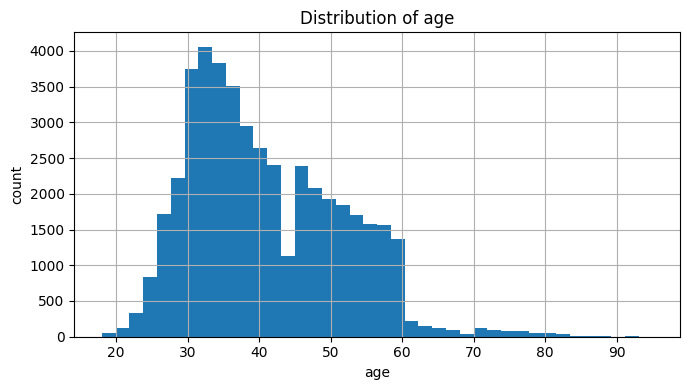

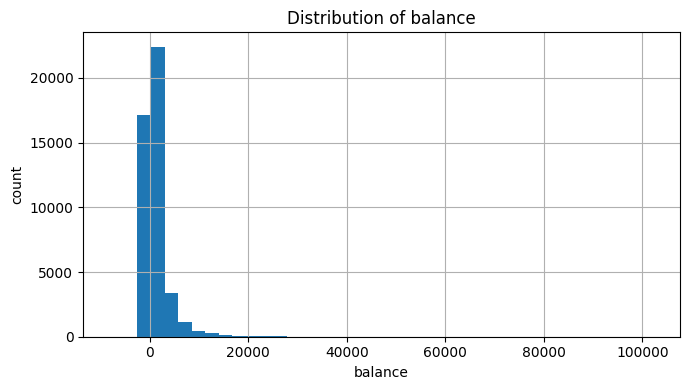

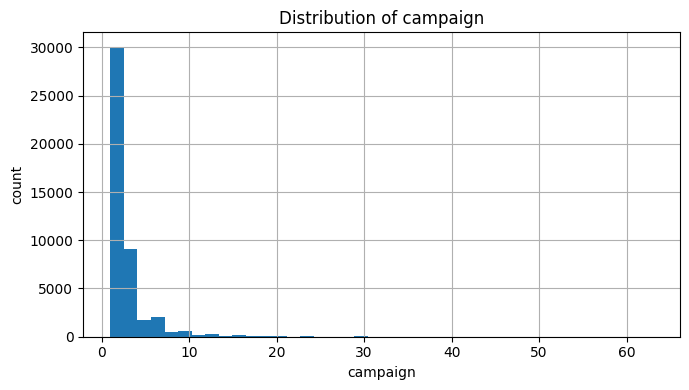

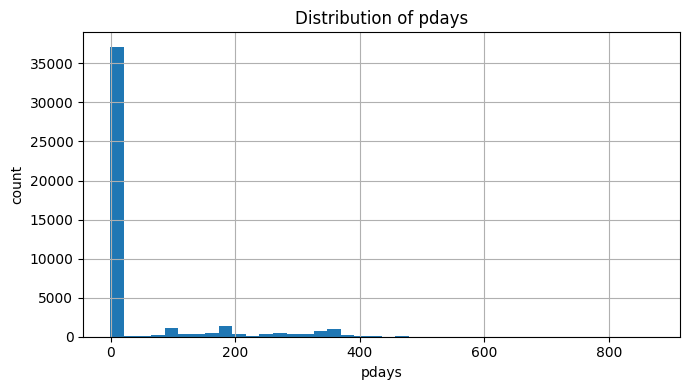

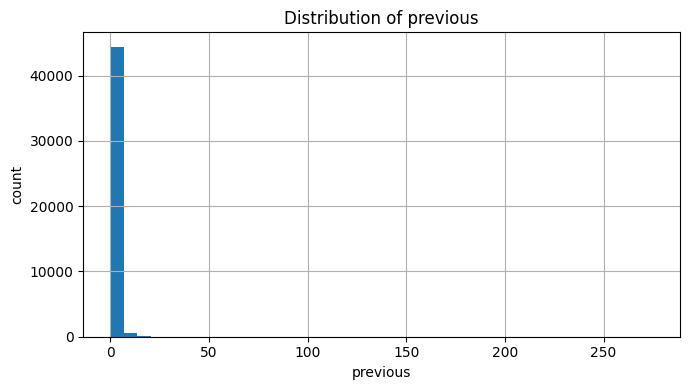

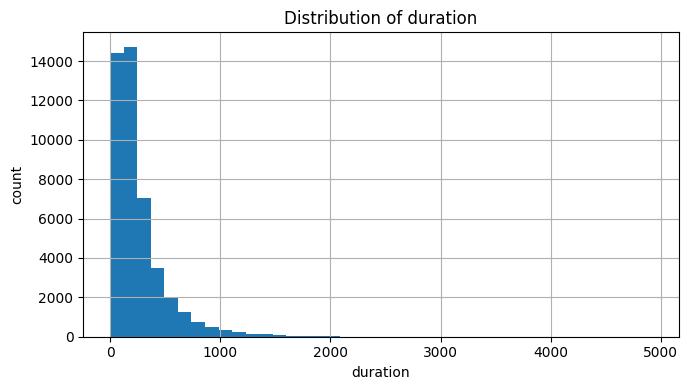

In [7]:
for column in ["age", "balance", "campaign", "pdays", "previous", "duration"]:
    if column in df.columns:
        plt.figure(figsize=(7, 4))
        df[column].hist(bins=40)
        plt.title(f"Distribution of {column}")
        plt.xlabel(column)
        plt.ylabel("count")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"eda_distribution_{column}.png", dpi=150)
        plt.show()

**Выводы по числовым признакам:**

- `balance` имеет выбросы и длинный хвост, поэтому добавляем логарифмический признак `balance_log_signed`.
- `campaign` тоже имеет выбросы, поэтому добавляем `campaign_capped`.
- `pdays = -1` означает, что клиента раньше не контактировали. Поэтому добавляем признак `was_previously_contacted`.
- `duration` сильно связан с результатом звонка, но до звонка он неизвестен.

## 5. Duration и data leakage

In [8]:
df_binary.groupby("y")["duration"].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
0,39922.0,221.182806,207.383237,0.0,95.0,164.0,279.0,4918.0
1,5289.0,537.294574,392.525262,8.0,244.0,426.0,725.0,3881.0


**Вывод:** `duration` нельзя использовать в основной модели для предварительного выбора клиентов.  
Этот признак становится известен только после завершения звонка. Если включить его в модель, качество будет искусственно завышено.  
Поэтому в основном train/validation/test split мы удаляем `duration`.